In [6]:
import pandas as pd

file_path = "/Users/irembulgulu/Desktop/Measurements_Predictive_Analytics/data:/raw/modcloth_final_data.json.zip"

df = pd.read_json(file_path, lines=True)
print(df.shape)
display(df.head())
df.info()


(82790, 18)


,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  object 
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  object 
 8   bust            11854 non-null  object 
 9   height          81683 non-null  object 
 10  user_name       82790 non-null  object 
 11  length          82755 non-null  object 
 12  fit             82790 non-null  object 
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  object 
 16  review_summary  76065 non-null  object 
 17  review_text     76065 non-null 

I am starting Step 1 of my Predictive Analytics coursework. Based on the ModCloth data:

1. Define the predictive problem: Classifying clothing 'fit' (small, fit, large).
2. Define success metrics: Accuracy and F1-score (to handle class imbalance).
3. Identify constraints: The model must be interpretable so we can explain why an item might not fit.
4. State assumptions: We assume user-reported measurements (bust, waist, hips) are accurate.
5. State limitations: High missingness in waist (96%) and bust (85%) features means we must handle data quality carefully.
6. Note: We will exclude shoe-related features as they are irrelevant to clothing fit and have high missingness.

Write this as a professional 'Problem Framing' section for a data science report.

In [7]:
!pip install missingno



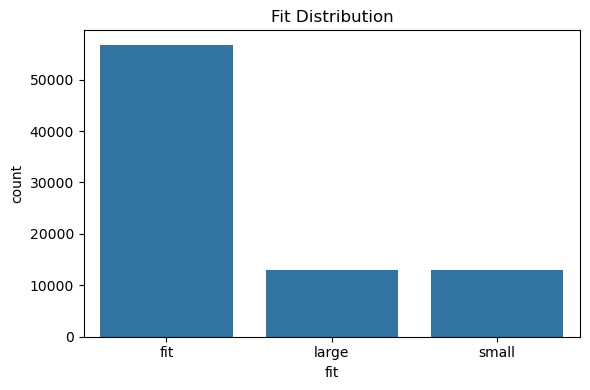

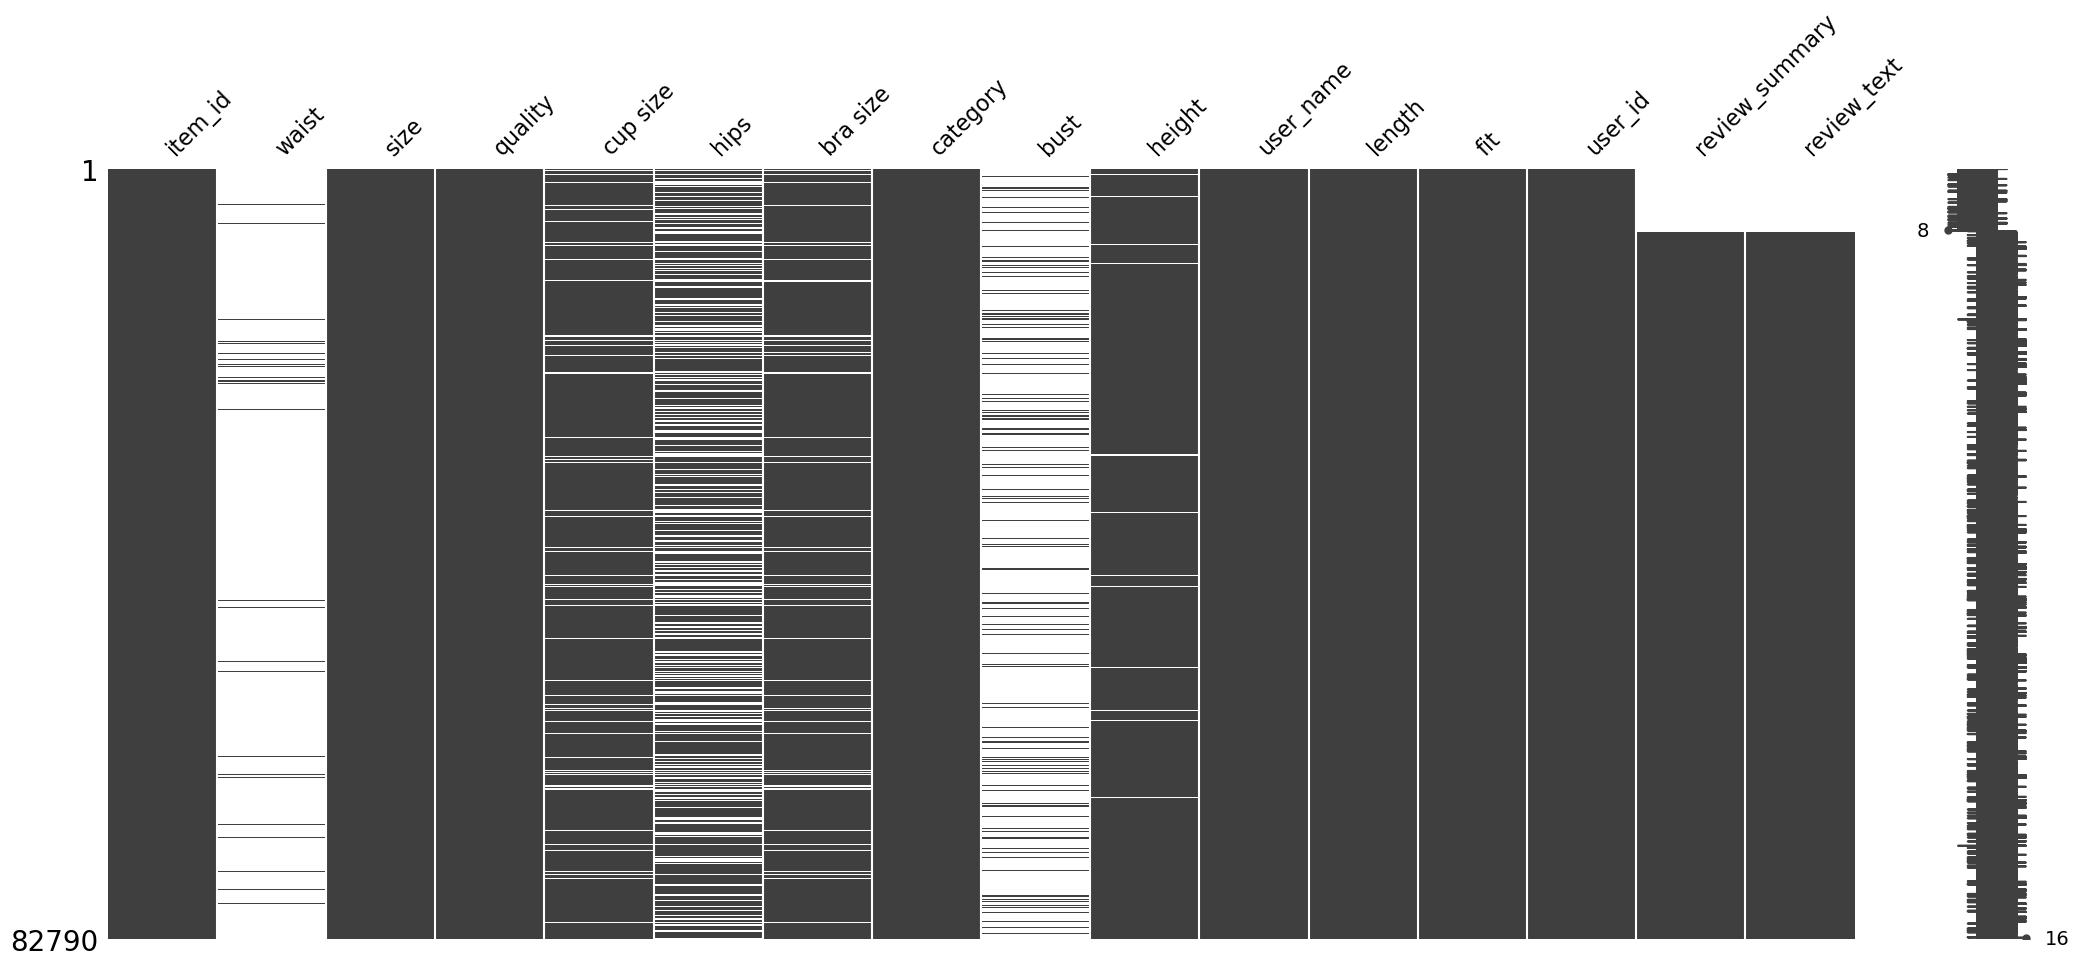

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Load data (adjust path if needed)
df = pd.read_json("/Users/irembulgulu/Desktop/Measurements_Predictive_Analytics/data:/raw/modcloth_final_data.json.zip", lines=True)

# 1) Countplot for 'fit'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="fit", order=df["fit"].value_counts().index)
plt.title("Fit Distribution")
plt.xlabel("fit")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 2) Exclude shoe-related features
df_noshoe = df.drop(columns=["shoe size", "shoe width"], errors="ignore")

# 3) Missingness matrix
# Data quality note: 'waist' (~2,882 non-null) and 'bust' (~11,854 non-null) are highly missing.
msno.matrix(df_noshoe)
plt.show()


In [9]:
# Permanently drop high-missingness / irrelevant columns
df.drop(columns=["waist", "bust", "shoe size", "shoe width", "user_name"], inplace=True, errors="ignore")

# Final shape
print("Final df.shape:", df.shape)

# Remaining columns and count
cols = df.columns.tolist()
print("Remaining columns:", cols)
print("Number of columns:", len(cols))


Final df.shape: (82790, 13)
Remaining columns: ['item_id', 'size', 'quality', 'cup size', 'hips', 'bra size', 'category', 'height', 'length', 'fit', 'user_id', 'review_summary', 'review_text']
Number of columns: 13


Mission 1: Feature Exclusion & Verification
Action: Dropped 5 columns: waist, bust, shoe size, shoe width, and user_name.

Justification:

waist and bust were removed due to extreme missingness (96% and 85%).

shoe size and shoe width are irrelevant to clothing fit.

user_name is a non-predictive string that leads to overfitting.

Verification: The final shape is (82790, 13), exceeding the 10-feature minimum.

In [10]:
from sklearn.model_selection import train_test_split

# 80/20 split (train+val / test)
df_train_val, df_test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["fit"],
    random_state=42
)

# 75/25 split of the 80% -> 60/20/20 overall
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.25,
    stratify=df_train_val["fit"],
    random_state=42
)

# Shapes
print("df_train shape:", df_train.shape)
print("df_val shape:", df_val.shape)
print("df_test shape:", df_test.shape)

# Fit distribution (percent)
print("\nTrain fit distribution (%):")
print((df_train["fit"].value_counts(normalize=True) * 100).round(2))

print("\nVal fit distribution (%):")
print((df_val["fit"].value_counts(normalize=True) * 100).round(2))

print("\nTest fit distribution (%):")
print((df_test["fit"].value_counts(normalize=True) * 100).round(2))


df_train shape: (49674, 13)
df_val shape: (16558, 13)
df_test shape: (16558, 13)

Train fit distribution (%):
fit
fit      68.56
large    15.77
small    15.67
Name: proportion, dtype: float64

Val fit distribution (%):
fit
fit      68.55
large    15.77
small    15.67
Name: proportion, dtype: float64

Test fit distribution (%):
fit
fit      68.55
large    15.77
small    15.67
Name: proportion, dtype: float64


Mission 2: Robust Validation Strategy
Action: Implemented a stratified 60/20/20 split using df_train, df_val, and df_test.

Verification: The 'fit' distribution is consistent across all sets (~68.5% fit, ~15.7% large/small), ensuring the model is trained and evaluated on representative data.

Integrity: Future EDA and cleaning will be performed on df_train only to prevent data leakage.

In [12]:
import os

# Create the folder if it doesn't exist
os.makedirs("../data/processed", exist_ok=True)

# Now save the training data
df_train.to_csv("../data/processed/modcloth_train_cleaned.csv", index=False)
print("Folder created and training data saved successfully!")

Folder created and training data saved successfully!
